<a href="https://colab.research.google.com/github/tharak-bairneni/eda-assignment/blob/main/EDA_Assignment_TharakBairneni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib

In [4]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Task 1: Distribution Analysis Using Histograms

Histogram with 5 Bins

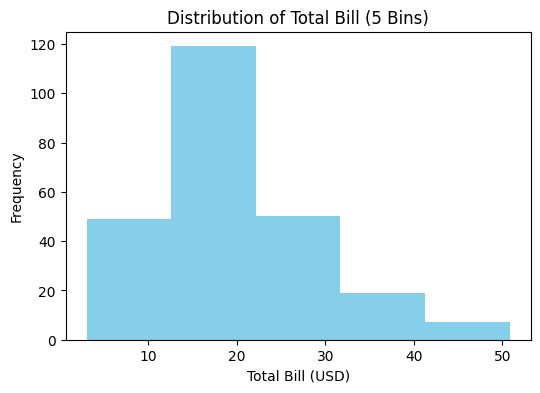

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df['total_bill'], bins=5, color='skyblue')

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (5 Bins)")

plt.show()

Histogram with 20 Bins

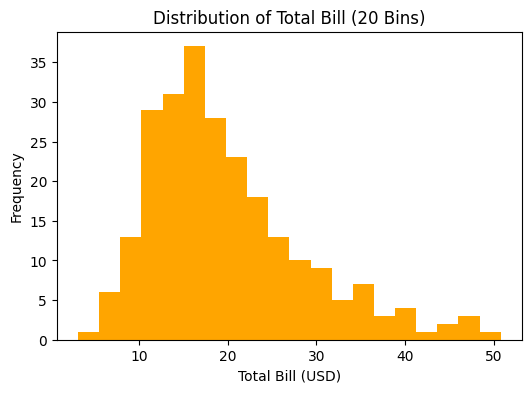

In [6]:
plt.figure(figsize=(6,4))

plt.hist(df['total_bill'], bins=20, color='orange')

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (20 Bins)")

plt.show()

Distribution Shape

The distribution of total_bill appears right-skewed.
Most restaurant bills fall in the lower range (around $10–$20), while fewer transactions occur at higher bill amounts.

Effect of Changing Bin Size

When using 5 bins, the distribution looks more generalized and less detailed.
With 20 bins, the plot reveals more subtle patterns and clusters in the data.
Increasing the number of bins provides more detail but can also make the chart appear noisy if too many bins are used.

Task 2: Outlier Detection Using Box Plots

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.boxplot(x='day', y='total_bill', data=df)

plt.xlabel("Day of the Week")
plt.ylabel("Total Bill (USD)")
plt.title("Total Bill Distribution by Day")

plt.show()

Highest Median Total Bill

From the box plot, Saturday (Sat) appears to have the highest median total bill among all days.

Detecting Outliers Using IQR

We calculate IQR for Saturday.

In [7]:
sat_data = df[df['day'] == 'Sat']['total_bill']

Q1 = sat_data.quantile(0.25)
Q3 = sat_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 13.905000000000001
Q3: 24.740000000000002
IQR: 10.835
Lower Bound: -2.3475
Upper Bound: 40.99250000000001


Any value outside the calculated lower or upper bounds is considered an outlier.
These values correspond to the points shown outside the whiskers in the box plot.

Task 3: Multi-Variable Comparison Using Plotly

In [8]:
#Install Plotly (if needed)
!pip install plotly

In [9]:
import plotly.express as px

fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="time",
    hover_data=["day","size"],
    title="Relationship Between Total Bill and Tip Amount"
)

fig.show()

Relationship Between Total Bill and Tip

There appears to be a positive relationship between total bill and tip amount.
As the total bill increases, the tip amount generally increases as well. This indicates that tipping is often proportional to the bill amount.

Difference Between Lunch and Dinner

Dinner transactions appear more frequently and generally involve higher total bills and tips compared to lunch. The color separation in the scatter plot helps visually distinguish these patterns.

Interesting Data Point

One interesting observation is a data point where the total bill is very high (above $45) with a relatively large tip.
This point likely represents a large group dining event or a special occasion, which results in both a higher bill and tip.